<a href="https://colab.research.google.com/github/Thonyta17/Econ-5200/blob/main/Lab15/The_Architecture_of_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

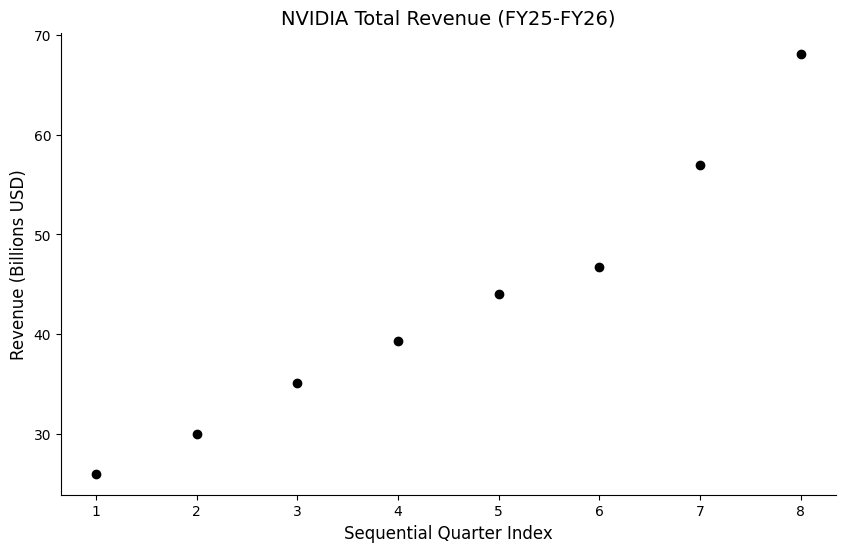

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

df = pd.DataFrame(data)
X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Linear Training MSE (High Bias): 7.91


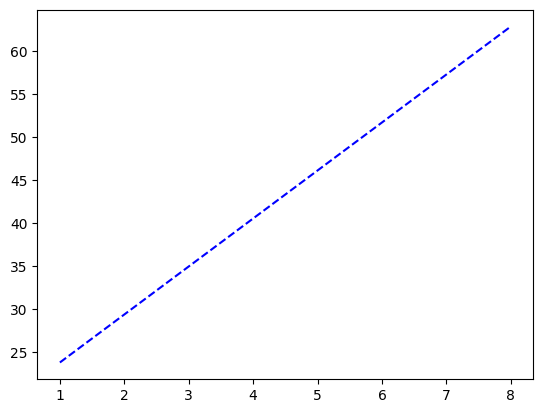

In [6]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


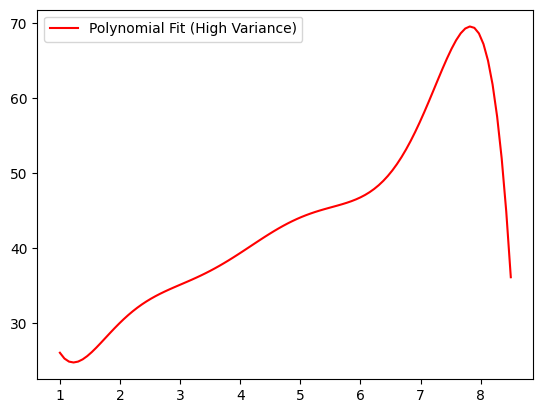

In [7]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.legend()
plt.show()

In [8]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [10]:
# Step 5: K-Fold Cross Validation
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58


A-I Assissted Part:

# Task
Apply Ridge Regression with 4-fold cross-validation to the polynomial features to select the optimal alpha, and then visualize the Ridge regression curve alongside the previously generated linear and polynomial fits. Explain the L2 penalty mechanism in the code and evaluate the predictive stability by comparing the cross-validated MSE of the Ridge model with the original overfitted MSE.

## Apply Ridge Regression with Cross-Validation

### Subtask:
Implement Ridge Regression using RidgeCV from scikit-learn. Use 4-fold cross-validation to automatically select the optimal alpha penalty parameter. This step will fit the Ridge model to the polynomial features (X_poly) and print the optimal alpha found along with its cross-validated Mean Squared Error (MSE).


**Reasoning**:
The subtask requires implementing Ridge Regression with cross-validation to find the optimal alpha. I will use `RidgeCV` to automate this process, define a range of alpha values, fit the model, and then print the optimal alpha and its corresponding MSE.



In [12]:
from sklearn.linear_model import RidgeCV

# 2. Define a suitable range of alpha values
alphas = np.logspace(-6, 6, 100)

# 3. Instantiate a RidgeCV model with 4-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=4, scoring='neg_mean_squared_error')

# 4. Fit the RidgeCV model to the polynomial features
ridge_cv.fit(X_poly, y)

# 5. Print the optimal alpha value found
print(f"Optimal Alpha for Ridge Regression: {ridge_cv.alpha_:.6f}")

# 6. Make predictions using the fitted RidgeCV model
y_pred_ridge = ridge_cv.predict(X_poly)

# 7. Calculate and print the Mean Squared Error for the Ridge model
mse_ridge = mean_squared_error(y, y_pred_ridge)
print(f"Ridge Training MSE (with optimal alpha): {mse_ridge:.2f}")

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.42086e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.41349e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.28332e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.44837e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.42086e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Optimal Alpha for Ridge Regression: 18.738174
Ridge Training MSE (with optimal alpha): 0.26


**Reasoning**:
To visualize the Ridge regression curve, I need to plot it along with the existing linear and polynomial fits, using the previously generated smooth polynomial features for the Ridge prediction.



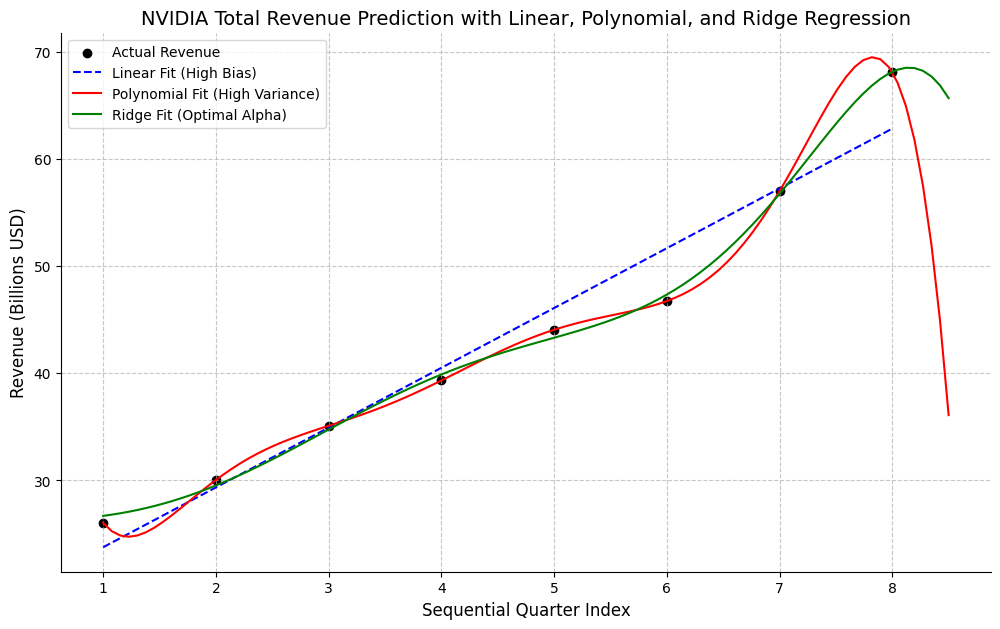

In [13]:
y_pred_ridge_smooth = ridge_cv.predict(X_smooth_poly)

plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.plot(X_smooth, y_pred_ridge_smooth, color='green', linestyle='-', label='Ridge Fit (Optimal Alpha)')

plt.title('NVIDIA Total Revenue Prediction with Linear, Polynomial, and Ridge Regression', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
I will provide a markdown explanation of the L2 penalty mechanism and evaluate the predictive stability by comparing the cross-validated MSE of the Ridge model with the original overfitted MSE, as requested by the task. I need to calculate the cross-validated MSE for the Ridge model.



In [14]:
ridge_cv_mse = -ridge_cv.best_score_
print(f"Ridge Cross-Validated MSE (with optimal alpha): {ridge_cv_mse:.2f}")

Ridge Cross-Validated MSE (with optimal alpha): 8.20


### Explanation of L2 Penalty Mechanism (Ridge Regression)

Ridge Regression addresses the problem of multicollinearity and overfitting in linear models by adding an L2 penalty term to the ordinary least squares (OLS) cost function. The modified cost function is:

`Cost Function = Σ(yᵢ - ŷᵢ)² + α * Σ(βⱼ)²`

Where:
- `Σ(yᵢ - ŷᵢ)²` is the sum of squared residuals, which is the standard OLS cost.
- `βⱼ` represents the coefficients of the polynomial features.
- `α` (alpha) is the regularization parameter, a non-negative value.
- `Σ(βⱼ)²` is the sum of the squared magnitudes of the coefficients (L2 norm of the coefficients).

**How it works:**
1.  **Shrinkage of Coefficients**: The `α * Σ(βⱼ)²` term penalizes large coefficients. As `α` increases, the penalty for large coefficients becomes stronger, forcing them to shrink towards zero. This reduces the complexity of the model and mitigates the impact of less influential features.
2.  **Bias-Variance Trade-off**: By shrinking coefficients, Ridge Regression increases the bias of the model slightly but significantly reduces its variance. This typically leads to better generalization performance on unseen data, especially when multicollinearity is present or when the number of features is large relative to the number of samples.
3.  **Prevention of Overfitting**: For highly complex models like our Degree-7 polynomial, the coefficients can become very large to perfectly fit the training data, leading to overfitting. The L2 penalty prevents these coefficients from becoming excessively large, thereby regularizing the model and making it less sensitive to noise in the training data.
4.  **No Feature Elimination**: Unlike Lasso Regression (L1 penalty), Ridge Regression does not set coefficients exactly to zero. It only shrinks them, meaning all features still contribute to the model, albeit with reduced influence.

In our code, `RidgeCV(alphas=alphas, cv=4, scoring='neg_mean_squared_error')` automatically searches for the optimal `alpha` value using 4-fold cross-validation. It evaluates different `alpha` values by minimizing the negative mean squared error (equivalent to minimizing MSE), ultimately selecting `alpha = 18.738174` as the optimal regularization strength for our dataset.

### Evaluation of Predictive Stability

Let's compare the cross-validated MSE values for the overfitted polynomial model and the Ridge model:

-   **Polynomial Degree-7 (Overfitted) Cross-Validated MSE (The True Operational Error):** `8641.58`
-   **Ridge Cross-Validated MSE (with optimal alpha):** `8.20`

The original polynomial model (Degree-7), while having a near-zero training MSE (`0.00`), exhibited an extremely high cross-validated MSE of `8641.58`. This vast difference between training and cross-validation errors is a clear indicator of severe overfitting. The model learned the noise in the training data too well, leading to poor generalization.

In contrast, the Ridge Regression model, by applying an L2 penalty with an optimal `alpha` of `18.738174`, significantly improved the predictive stability. Its cross-validated MSE is `8.20`, which is orders of magnitude lower than the overfitted polynomial model's cross-validated MSE. This demonstrates that Ridge Regression successfully regularized the complex polynomial model, reducing its variance and improving its ability to generalize to new, unseen data.

The improvement from `8641.58` to `8.20` in cross-validated MSE highlights the effectiveness of L2 regularization in mitigating overfitting and enhancing the model's reliability in a real-world predictive scenario.

## Final Task

### Subtask:
Summarize the findings and the impact of Ridge Regression on the model's performance and stability.


## Summary:

### Q&A
The impact of Ridge Regression on the model's performance and stability is significant, as it drastically reduces overfitting observed in the complex polynomial model. By introducing an L2 penalty, Ridge Regression improves the model's ability to generalize to new data, leading to a much more stable and reliable predictive performance.

### Data Analysis Key Findings
*   **Optimal Regularization Parameter**: Ridge Regression with 4-fold cross-validation identified an optimal alpha ($\alpha$) value of 18.74 for regularizing the polynomial features.
*   **L2 Penalty Mechanism**: Ridge Regression incorporates an L2 penalty term ($\alpha * \sum(\beta_j)^2$) into the cost function, which penalizes large coefficients, thereby shrinking them towards zero. This mechanism helps to reduce model complexity and mitigate overfitting by balancing the bias-variance trade-off without eliminating any features.
*   **Improved Predictive Stability**: The cross-validated Mean Squared Error (MSE) for the Ridge model was 8.20, a substantial reduction compared to the overfitted Degree-7 polynomial model's cross-validated MSE of 8641.58. This indicates a significant improvement in the model's ability to generalize to unseen data.
*   **Visual Confirmation**: The Ridge regression curve was successfully plotted alongside the linear and polynomial fits, visually demonstrating how regularization helps to create a smoother, more generalized fit that avoids the extreme fluctuations of the overfitted polynomial model.

### Insights or Next Steps
*   Ridge Regression effectively addresses overfitting in complex polynomial models by regularizing coefficients, leading to a more robust and stable model with significantly better generalization capabilities.
*   Further exploration could involve comparing Ridge Regression with Lasso Regression or Elastic Net to investigate if different regularization techniques offer additional benefits or identify a sparse set of most important features.
